<style>
/* Minimal fixes only: keep the existing site design, but make notebook code and wide tables usable. */
.highlight pre,
div.highlight,
div.input_area,
div.output_area pre {
  background: #1f1f1f !important;
  color: #f8f8f2 !important;
  border-color: #444 !important;
}
.highlight span { color: inherit !important; }
.rendered_html,
.jp-RenderedHTMLCommon {
  max-width: 100%;
  overflow-x: auto;
  -webkit-overflow-scrolling: touch;
}
.rendered_html table,
.jp-RenderedHTMLCommon table {
  display: block;
  width: max-content;
  max-width: 100%;
  min-width: 680px;
  overflow-x: auto;
  -webkit-overflow-scrolling: touch;
}
.rendered_html td,
.rendered_html th,
.jp-RenderedHTMLCommon td,
.jp-RenderedHTMLCommon th {
  white-space: nowrap;
}

.output_svg svg,
.rendered_html > svg,
.jp-RenderedHTMLCommon > svg {
  display: block;
  width: 100% !important;
  max-width: 100%;
  height: auto;
}
.highlight .k, .highlight .kn, .highlight .kd, .highlight .kc { color: #cc7832 !important; }
.highlight .s, .highlight .s1, .highlight .s2, .highlight .sa { color: #6a8759 !important; }
.highlight .m, .highlight .mi, .highlight .mf { color: #6897bb !important; }
.highlight .c, .highlight .c1, .highlight .cm { color: #808080 !important; font-style: italic; }
.highlight .nf, .highlight .fm { color: #ffc66d !important; }
.highlight .nb, .highlight .bp { color: #a9b7c6 !important; }
.highlight .o, .highlight .ow, .highlight .p { color: #dcdcdc !important; }
.highlight .n, .highlight .nn, .highlight .nv { color: #a9b7c6 !important; }
.crawler-data { display: none !important; }
</style>

The dataset behind this article was generated from a resumable local SQLite checkpoint of the public 2026 CrossFit Open leaderboard API. I exported the normalized tables into a compact GitHub Release asset, excluded raw API response bodies, converted height and weight to metric units, and use the release download below as the source for the rest of the analysis.

The main reader question is percentile targeting: for a sex and age-group division, what rank and score correspond to a given percentile? The release can answer that across the leaderboard. Public profile benchmarks answer a narrower question because those fields are self-reported and often blank.


## Load the release asset

The tarball lives as a GitHub Release asset. The notebook downloads it, verifies the SHA-256, and loads the CSVs from the extracted archive.

Release asset: <https://github.com/leblancfg/leblancfg.github.io/releases/download/crossfit-open-2026-compact-v1/crossfit-open-2026-compact-v1.tar.gz>. Checksum file: <https://github.com/leblancfg/leblancfg.github.io/releases/download/crossfit-open-2026-compact-v1/SHA256SUMS>.


In [1]:
from __future__ import annotations

import csv
import hashlib
import html
import json
import tarfile
import urllib.request
from collections import defaultdict
from pathlib import Path

from IPython.display import HTML, Markdown, SVG, display

RELEASE_TAG = "crossfit-open-2026-compact-v1"
ASSET_NAME = "crossfit-open-2026-compact-v1.tar.gz"
ASSET_URL = f"https://github.com/leblancfg/leblancfg.github.io/releases/download/{RELEASE_TAG}/{ASSET_NAME}"
EXPECTED_SHA256 = "742f89eed0fa381570111b8b0fb82d97a44d40d13c14a3fcf6bfcd848a6751dd"
CACHE_DIR = Path.home() / ".cache" / "leblancfg" / RELEASE_TAG
ARCHIVE_PATH = CACHE_DIR / ASSET_NAME
EXTRACTED_DIR = CACHE_DIR / "crossfit-open-2026-compact-v1"

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def safe_extract(tar: tarfile.TarFile, destination: Path) -> None:
    destination = destination.resolve()
    for member in tar.getmembers():
        target = (destination / member.name).resolve()
        if destination not in target.parents and target != destination:
            raise RuntimeError(f"unsafe tar member: {member.name}")
    tar.extractall(destination)

CACHE_DIR.mkdir(parents=True, exist_ok=True)
if not ARCHIVE_PATH.exists():
    urllib.request.urlretrieve(ASSET_URL, ARCHIVE_PATH)

actual_sha256 = sha256_file(ARCHIVE_PATH)
assert actual_sha256 == EXPECTED_SHA256, actual_sha256

if not (EXTRACTED_DIR / "metadata.json").exists():
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        safe_extract(tar, CACHE_DIR)

display(Markdown(f"Downloaded `{ASSET_NAME}` and verified SHA-256 `{actual_sha256}`."))


Downloaded `crossfit-open-2026-compact-v1.tar.gz` and verified SHA-256 `742f89eed0fa381570111b8b0fb82d97a44d40d13c14a3fcf6bfcd848a6751dd`.

In [2]:
def load_csv(name: str) -> list[dict[str, str]]:
    with (EXTRACTED_DIR / name).open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

def int_or_none(value: str | None) -> int | None:
    return int(value) if value not in (None, "") else None

def float_or_none(value: str | None) -> float | None:
    return float(value) if value not in (None, "") else None

def fmt_int(value: int | str | None) -> str:
    if value in (None, ""):
        return ""
    return f"{int(value):,}"



def hidden_html_table(headers: list[str], rows: list[list[object]], *, label: str) -> HTML:
    header_html = "".join(f"<th>{html.escape(str(header))}</th>" for header in headers)
    body_html = "".join(
        "<tr>" + "".join(f"<td>{html.escape(str(value))}</td>" for value in row) + "</tr>"
        for row in rows
    )
    table = f'<table data-label="{html.escape(label)}"><thead><tr>{header_html}</tr></thead><tbody>{body_html}</tbody></table>'
    return HTML(f'<div class="crawler-data" aria-hidden="true">{table}</div>')

def markdown_table(headers: list[str], rows: list[list[object]]) -> Markdown:
    def cell(value: object) -> str:
        return str(value).replace("|", "\|")
    lines = ["| " + " | ".join(headers) + " |"]
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")
    for row in rows:
        lines.append("| " + " | ".join(cell(value) for value in row) + " |")
    return Markdown("\n".join(lines))

metadata = json.loads((EXTRACTED_DIR / "metadata.json").read_text(encoding="utf-8"))
divisions = load_csv("divisions.csv")
athletes = load_csv("athletes.csv")
entries = load_csv("leaderboard_entries.csv")
scores = load_csv("workout_scores.csv")
benchmarks = load_csv("sample_benchmark_stats.csv")

def svg_escape(value: object) -> str:
    return str(value).replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")

def bar_svg(title: str, rows: list[dict[str, object]], *, note: str = "", left: int = 190, width: int = 940) -> str:
    right, top, bottom, bar_h, gap = 125, 58, 34, 22, 8
    max_value = max(float(row.get("scale_value", row["value"])) for row in rows) or 1
    plot_w = width - left - right
    height = top + bottom + len(rows) * (bar_h + gap) - gap
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}" role="img" aria-label="{svg_escape(title)}">']
    parts.append('<style>.cfchart-title{font:600 18px system-ui,-apple-system,Segoe UI,sans-serif;fill:#dcdcdc}.cfchart-label{font:12px system-ui,-apple-system,Segoe UI,sans-serif;fill:#a9b7c6}.cfchart-value{font:12px system-ui,-apple-system,Segoe UI,sans-serif;fill:#dcdcdc}.cfchart-note{font:12px system-ui,-apple-system,Segoe UI,sans-serif;fill:#808080}.cfchart-grid{stroke:#3c3f41;stroke-width:1}.cfchart-axis{stroke:#606366;stroke-width:1}</style>')
    parts.append(f'<rect width="{width}" height="{height}" fill="#2b2b2b" rx="6"/><text class="cfchart-title" x="18" y="30">{svg_escape(title)}</text>')
    if note:
        parts.append(f'<text class="cfchart-note" x="18" y="49">{svg_escape(note)}</text>')
    for tick in (0.25, 0.5, 0.75, 1.0):
        x = left + plot_w * tick
        parts.append(f'<line class="cfchart-grid" x1="{x:.1f}" y1="{top - 10}" x2="{x:.1f}" y2="{height - bottom + 4}"/>')
    parts.append(f'<line class="cfchart-axis" x1="{left}" y1="{top - 10}" x2="{left}" y2="{height - bottom + 4}"/>')
    for index, row in enumerate(rows):
        y = top + index * (bar_h + gap)
        bar_w = max(2, plot_w * (float(row.get("scale_value", row["value"])) / max_value))
        parts.append(f'<text class="cfchart-label" x="18" y="{y + 15}">{svg_escape(row["label"])}</text>')
        parts.append(f'<rect x="{left}" y="{y}" width="{bar_w:.1f}" height="{bar_h}" rx="3" fill="{row.get("color", "#6a8759")}"/>')
        parts.append(f'<text class="cfchart-value" x="{left + bar_w + 8:.1f}" y="{y + 15}">{svg_escape(row["display"])}</text>')
    return "".join(parts + ["</svg>"])

def small_multiples_svg(title: str, panels: list[dict[str, object]]) -> str:
    width, panel_w, left, right, bar_h, gap = 980, 455, 145, 80, 18, 7
    panel_h, panel_gap_y, top_title = 181, 26, 48
    height = top_title + 2 * panel_h + panel_gap_y + 52
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}" role="img" aria-label="{svg_escape(title)}">']
    parts.append('<style>.cfchart-title{font:600 18px system-ui,-apple-system,Segoe UI,sans-serif;fill:#dcdcdc}.cfchart-panel{font:600 14px system-ui,-apple-system,Segoe UI,sans-serif;fill:#ffc66d}.cfchart-label{font:11px system-ui,-apple-system,Segoe UI,sans-serif;fill:#a9b7c6}.cfchart-value{font:11px system-ui,-apple-system,Segoe UI,sans-serif;fill:#dcdcdc}.cfchart-grid{stroke:#3c3f41;stroke-width:1}.cfchart-axis{stroke:#606366;stroke-width:1}</style>')
    parts.append(f'<rect width="{width}" height="{height}" fill="#2b2b2b" rx="6"/><text class="cfchart-title" x="18" y="30">{svg_escape(title)}</text>')
    for panel_index, panel in enumerate(panels):
        col, row_num = panel_index % 2, panel_index // 2
        x0, y0 = 18 + col * (panel_w + 28), top_title + row_num * (panel_h + panel_gap_y)
        plot_w = panel_w - left - right
        rows = panel["rows"]
        max_value = max(float(row["value"]) for row in rows) or 1
        parts.append(f'<text class="cfchart-panel" x="{x0}" y="{y0 + 16}">{svg_escape(panel["title"])}</text>')
        parts.append(f'<line class="cfchart-axis" x1="{x0 + left}" y1="{y0 + 26}" x2="{x0 + left}" y2="{y0 + panel_h - 12}"/>')
        for index, item in enumerate(rows):
            y = y0 + 26 + index * (bar_h + gap)
            bar_w = max(2, plot_w * (float(item.get("scale_value", item["value"])) / max_value))
            parts.append(f'<text class="cfchart-label" x="{x0}" y="{y + 13}">{svg_escape(item["label"])}</text>')
            parts.append(f'<rect x="{x0 + left}" y="{y}" width="{bar_w:.1f}" height="{bar_h}" rx="3" fill="{item.get("color", "#6a8759")}"/>')
            parts.append(f'<text class="cfchart-value" x="{x0 + left + bar_w + 6:.1f}" y="{y + 13}">{svg_escape(item["display"])}</text>')
    return "".join(parts + ["</svg>"])

def display_svg(svg: str) -> None:
    display(SVG(svg))


## Reproduce the release counts

The release contains the complete normalized leaderboard crawl for every 2026 Open division. The SQLite checkpoint had raw fetch bodies too; those are deliberately absent here.


In [3]:
actual_counts = {
    "divisions.csv": len(divisions),
    "athletes.csv": len(athletes),
    "leaderboard_entries.csv": len(entries),
    "workout_scores.csv": len(scores),
    "sample_benchmark_stats.csv": len(benchmarks),
}
count_rows = []
for filename, expected in metadata["exported_row_counts"].items():
    actual = actual_counts[filename]
    count_rows.append([filename, fmt_int(expected), fmt_int(actual), "yes" if expected == actual else "no"])
display(markdown_table(["File", "Metadata rows", "Loaded rows", "Matches"], count_rows))


| File | Metadata rows | Loaded rows | Matches |
| --- | --- | --- | --- |
| divisions.csv | 23 | 23 | yes |
| athletes.csv | 254,531 | 254,531 | yes |
| leaderboard_entries.csv | 388,423 | 388,423 | yes |
| workout_scores.csv | 1,165,269 | 1,165,269 | yes |
| sample_benchmark_stats.csv | 165 | 165 | yes |

## Percentile cutoffs by sex and age-group division

Percentiles here are rank-derived. For a division with `N` athletes, the percentile for rank `r` is:

```text
percentile = 100 * (1 - ((r - 1) / (N - 1)))
```

The cutoff is the worst rank still at or above the requested percentile. Because ties can share a rank, `athletes_at_or_above` can differ slightly from the rank number. The notebook validates the stored `performance_percentile` column against the rank formula, then uses common target percentiles so a reader can ask about 75th, 80th, 85th, 90th, 95th, or 99th without rerunning the crawl.


Division,Percentile,Division size,Rank cutoff,Ties at cutoff,Athletes at/above,Overall score
Men,50th,"127,113","63,557",1,"63,557","193,186"
Men,75th,"127,113","31,779",1,"31,779","103,601"
Men,80th,"127,113","25,423",1,"25,423","85,961"
Men,85th,"127,113","19,066",2,"19,067","67,296"
Men,90th,"127,113","12,712",1,"12,712","47,632"
Men,95th,"127,113","6,356",1,"6,356","25,748"
Men,99th,"127,113","1,272",1,"1,272","5,879"
Women,50th,"105,959","52,980",1,"52,980","161,846"
Women,75th,"105,959","26,490",1,"26,490","86,347"
Women,80th,"105,959","21,192",2,"21,193","69,556"


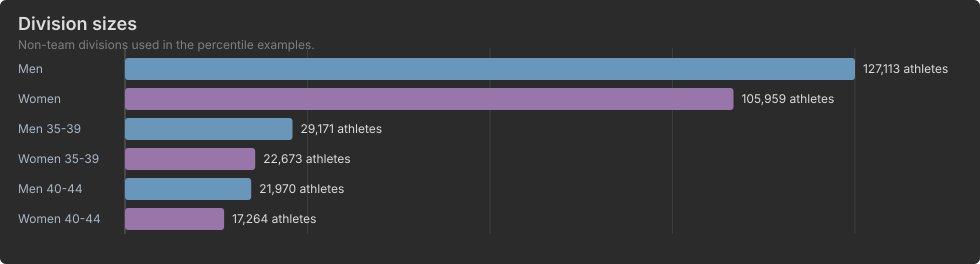

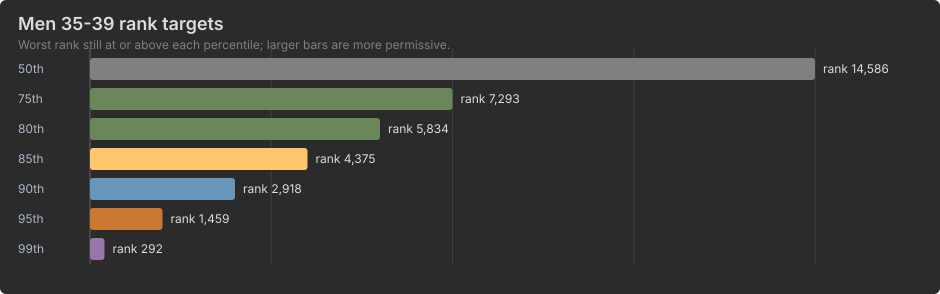

In [4]:
division_by_id = {row["division_id"]: row for row in divisions if row["category"] != "team"}
entries_by_division: dict[str, list[dict[str, str]]] = defaultdict(list)
for row in entries:
    if row["division_id"] in division_by_id:
        entries_by_division[row["division_id"]].append(row)

for division_entries in entries_by_division.values():
    division_size = len(division_entries)
    for row in division_entries:
        rank = int_or_none(row["overall_rank"])
        stored_percentile = float_or_none(row["performance_percentile"])
        if rank is None or stored_percentile is None or division_size <= 1:
            continue
        computed_percentile = 100 * (1 - ((rank - 1) / (division_size - 1)))
        assert abs(computed_percentile - stored_percentile) < 0.01

COMMON_PERCENTILES = (50, 75, 80, 85, 90, 95, 99)
FOCUS_DIVISIONS = ("Men", "Women", "Men 35-39", "Women 35-39", "Men 40-44", "Women 40-44")

cutoffs = []
for division_id, division_entries in entries_by_division.items():
    division = division_by_id[division_id]
    division_size = len(division_entries)
    rows_by_rank: dict[int, list[dict[str, str]]] = defaultdict(list)
    for entry in division_entries:
        rank = int_or_none(entry["overall_rank"])
        if rank is not None:
            rows_by_rank[rank].append(entry)
    sorted_ranks = sorted(rows_by_rank)
    for percentile in COMMON_PERCENTILES:
        rank_limit = 1 + ((100 - percentile) / 100) * (division_size - 1)
        cutoff_rank = max(rank for rank in sorted_ranks if rank <= rank_limit)
        cutoff_tied_rows = sorted(
            rows_by_rank[cutoff_rank],
            key=lambda row: int(row["athlete_id"]) if row["athlete_id"].isdigit() else row["athlete_id"],
        )
        cutoff_row = cutoff_tied_rows[0]
        athletes_at_or_above = sum(len(rows_by_rank[rank]) for rank in sorted_ranks if rank <= cutoff_rank)
        cutoffs.append({
            "sex": division["sex"],
            "division_name": division["division_name"],
            "percentile": percentile,
            "division_size": division_size,
            "rank_cutoff": cutoff_rank,
            "tie_count_at_cutoff": len(cutoff_tied_rows),
            "athletes_at_or_above": athletes_at_or_above,
            "athlete_id": cutoff_row["athlete_id"],
            "overall_score": cutoff_row["overall_score"],
            "division_id": division_id,
        })

def cutoff_for(division_name: str, percentile: int) -> dict[str, object]:
    return next(item for item in cutoffs if item["division_name"] == division_name and item["percentile"] == percentile)

lookup_rows = []
for division_name in FOCUS_DIVISIONS:
    for percentile in COMMON_PERCENTILES:
        row = cutoff_for(division_name, percentile)
        lookup_rows.append([
            division_name,
            f"{percentile}th",
            fmt_int(row["division_size"]),
            fmt_int(row["rank_cutoff"]),
            fmt_int(row["tie_count_at_cutoff"]),
            fmt_int(row["athletes_at_or_above"]),
            fmt_int(row["overall_score"]),
        ])

display(hidden_html_table(
    ["Division", "Percentile", "Division size", "Rank cutoff", "Ties at cutoff", "Athletes at/above", "Overall score"],
    lookup_rows,
    label="division percentile lookup",
))

chart_colors = {50: "#808080", 75: "#6a8759", 80: "#6a8759", 85: "#ffc66d", 90: "#6897bb", 95: "#cc7832", 99: "#9876aa"}
division_size_rows = []
for division_name in FOCUS_DIVISIONS:
    row = cutoff_for(division_name, 50)
    division_size_rows.append({
        "label": division_name,
        "value": row["division_size"],
        "display": f"{fmt_int(row['division_size'])} athletes",
        "color": "#6897bb" if row["sex"] == "M" else "#9876aa",
    })

display_svg(bar_svg("Division sizes", division_size_rows, note="Non-team divisions used in the percentile examples.", left=125, width=980))

men_3539_rank_rows = []
for percentile in COMMON_PERCENTILES:
    row = cutoff_for("Men 35-39", percentile)
    men_3539_rank_rows.append({
        "label": f"{percentile}th",
        "value": row["rank_cutoff"],
        "display": f"rank {fmt_int(row['rank_cutoff'])}",
        "color": chart_colors[percentile],
    })

display_svg(bar_svg("Men 35-39 rank targets", men_3539_rank_rows, note="Worst rank still at or above each percentile; larger bars are more permissive.", left=90))


The leaderboard target table is the part of the release with the strongest footing: it uses every normalized leaderboard entry. A coach or athlete can pick a division and percentile, then translate that to a rank cutoff and Open score boundary.

Men 35-39 is the worked example in the charts, but the table above carries the same calculation for the other common sex and age-group divisions.


| Men 35-39 percentile | Rank cutoff | Ties at cutoff | Overall score | 26.1 | 26.2 | 26.3 |
| --- | --- | --- | --- | --- | --- | --- |
| 50th | 14,586 | 1 | 44,171 | 192 reps | 91 reps | 161 reps |
| 75th | 7,293 | 1 | 23,967 | 232 reps | 120 reps | 161 reps |
| 80th | 5,834 | 2 | 19,861 | 210 reps / 242 reps | 115 reps / 125 reps | 181 reps / 191 reps |
| 85th | 4,375 | 2 | 15,634 | 238 reps / 245 reps | 119 reps / 121 reps | 187 reps / 189 reps |
| 90th | 2,918 | 1 | 11,119 | 230 reps | 12:55 | 202 reps |
| 95th | 1,459 | 2 | 6,205 | 248 reps / 285 reps | 12:54 / 12:59 | 196 reps / 215 reps |
| 99th | 292 | 1 | 1,431 | 281 reps | 10:43 | 241 reps |

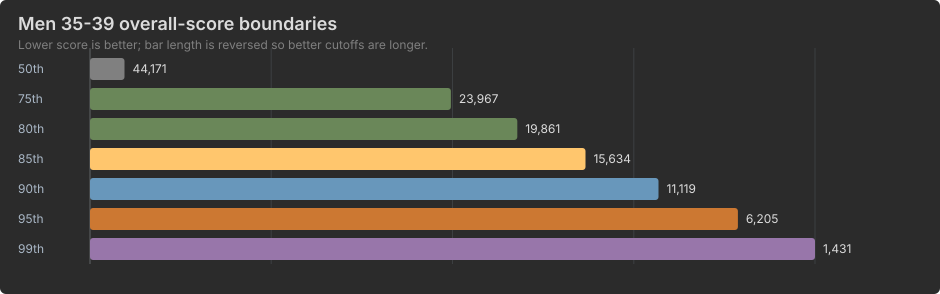

In [5]:
score_by_entry: dict[tuple[str, str], dict[int, str]] = defaultdict(dict)
for row in scores:
    score_by_entry[(row["division_id"], row["athlete_id"])][int(row["workout_ordinal"])] = row["score_display"]

def tied_workout_display(division_id: str, rank: int, workout_ordinal: int) -> str:
    tied_entries = [row for row in entries_by_division[division_id] if int_or_none(row["overall_rank"]) == rank]
    values = sorted({score_by_entry[(row["division_id"], row["athlete_id"])].get(workout_ordinal, "") for row in tied_entries})
    values = [value for value in values if value]
    if len(values) <= 3:
        return " / ".join(values)
    return " / ".join(values[:3]) + f" / +{len(values) - 3} more"

boundary_rows = []
for percentile in COMMON_PERCENTILES:
    row = cutoff_for("Men 35-39", percentile)
    division_id = str(row["division_id"])
    rank_cutoff = int(row["rank_cutoff"])
    boundary_rows.append([
        f"{percentile}th",
        fmt_int(row["rank_cutoff"]),
        fmt_int(row["tie_count_at_cutoff"]),
        fmt_int(row["overall_score"]),
        tied_workout_display(division_id, rank_cutoff, 1),
        tied_workout_display(division_id, rank_cutoff, 2),
        tied_workout_display(division_id, rank_cutoff, 3),
    ])

display(markdown_table(
    ["Men 35-39 percentile", "Rank cutoff", "Ties at cutoff", "Overall score", "26.1", "26.2", "26.3"],
    boundary_rows,
))

score_rows = []
score_values = [int(cutoff_for("Men 35-39", percentile)["overall_score"]) for percentile in COMMON_PERCENTILES]
worst_score, best_score = max(score_values), min(score_values)
for percentile in COMMON_PERCENTILES:
    row = cutoff_for("Men 35-39", percentile)
    score = int(row["overall_score"])
    score_rows.append({
        "label": f"{percentile}th",
        "value": score,
        "scale_value": (worst_score - score) + max(1, int(0.05 * (worst_score - best_score))),
        "display": fmt_int(score),
        "color": chart_colors[percentile],
    })

display_svg(bar_svg("Men 35-39 overall-score boundaries", score_rows, note="Lower score is better; bar length is reversed so better cutoffs are longer.", left=90))


For Men 35-39, the 75th percentile cutoff was rank 7,293 out of 29,171. The 90th percentile cutoff was rank 2,918, and the 95th percentile cutoff was rank 1,459. The table includes ties at the cutoff. When tied athletes have different workout scores, the workout columns show the distinct tied boundary values.

That is the practical use of the release: turn a target percentile into a rank, score, and set of boundary workout scores. The leaderboard percentile calculation is complete for the released divisions. The benchmark sections below are different: they use public profile fields, so their main risk is missingness and self-reporting bias.


## Benchmark profile caveats

The leaderboard tables answer the rank question directly. Benchmark fields need more care. They come from public CrossFit athlete profiles, are self-reported, and usually represent lifetime PR values.

The compact release includes a small `sample_benchmark_stats.csv` file for parser validation. The benchmark ladders here use a separate cutoff-window crawl of public profiles near selected leaderboard percentiles.

This is still not a benchmark census. Empty profile fields stay empty, and athletes who publish PRs may differ from athletes who leave profiles blank. Read these as published-profile medians near leaderboard cutoffs, not as true population benchmark percentiles.


In [6]:
from statistics import median

def seconds_to_mmss(seconds: float | int | None) -> str:
    if seconds in (None, ""):
        return ""
    seconds = int(round(float(seconds)))
    return f"{seconds // 60}:{seconds % 60:02d}"

def kg_to_lb(kg: float | int | None) -> float | None:
    return None if kg is None else float(kg) / 0.45359237

def safe_float(value: str | None) -> float | None:
    return float(value) if value not in (None, "") else None

athlete_by_id = {row["athlete_id"]: row for row in athletes}


## Public profile benchmark ladders

The targeted profile CSV is an add-on to the release: `/data/crossfit_open_2026_targeted_benchmark_stats_expanded.csv`. The matching manifest is `/data/crossfit_open_2026_targeted_profile_manifest_expanded.csv`. Together they cover athletes within ±15 ranks of the 75th, 80th, 85th, 90th, 95th, and 99th percentile cutoffs for Men, Women, Men 35-39, Women 35-39, Men 40-44, and Women 40-44.

Counts in the benchmark tables are coverage counts inside the cutoff window: valid metric profiles divided by targeted profiles. The window is usually 31 athletes unless the cutoff is near a division edge. Rows with one or two usable values are marked anecdotal.

Before taking medians, I filter obvious self-reporting mistakes for the four metrics used here. For example, the targeted crawl contains a 36-second 400m and a 51:13 400m; both are excluded from the 400m summary.

**Steady-state cardio: FTP-equivalent.** CrossFit profiles usually do not publish cycling FTP. The closest public profile test in this crawl is `Run 5k`. For a 5k run, estimate an FTP-like cycling value in W/kg by converting 5k speed into a critical-speed proxy, then applying an economy/efficiency bridge:

```text
running_speed_mps = 5000 / run_5k_seconds
critical_speed_mps = 0.92 * running_speed_mps
ftp_equivalent_wkg = critical_speed_mps * 4.184 * 0.23
```

The `4.184` term is the common running-energy-cost approximation of about 1 kcal/kg/km. The `0.23` term treats cycling FTP as external mechanical power at about 23% gross efficiency. This produces a steady-state engine equivalence from a published running test, not a lab-validated FTP prediction.

**High-energy cardio: 400m time.** Use `Run 400m` directly as a high-power cardio benchmark. Lower time is better:

```text
run_400_seconds = profile["Run 400m"].time_seconds
```

**Slow strength: CrossFit Total.** The closest slow-strength abstraction is CrossFit Total: back squat + shoulder press + deadlift. If a profile publishes all three components, reconstruct it directly:

```text
crossfit_total_kg = back_squat_1rm_kg + shoulder_press_1rm_kg + deadlift_1rm_kg
```

If one component is missing, leave the total missing.

**Fast strength: 1RM clean & jerk.** Use `Clean & Jerk 1RM` directly, shown in kilograms. It is the cleanest fast-strength proxy in the published profile fields because it combines speed, coordination, and maximal loading.


Target rows,Unique athletes,HTTP 200,HTTP 404,Profiles with any benchmark
961,959,959,2,443


### Steady-state cardio: FTP-equivalent near cutoff ranks

Division,Percentile,Median,Metric profiles,Target profiles,Anecdotal
Men,75th,3.34 W/kg,5,26,
Men,80th,3.46 W/kg,7,24,
Men,85th,3.48 W/kg,3,27,
Men,90th,3.45 W/kg,4,26,
Men,95th,3.32 W/kg,6,27,
Men,99th,3.46 W/kg,10,29,
Women,75th,2.90 W/kg,2,27,yes
Women,80th,2.77 W/kg,3,27,
Women,85th,2.99 W/kg,2,30,yes
Women,90th,3.28 W/kg,4,28,


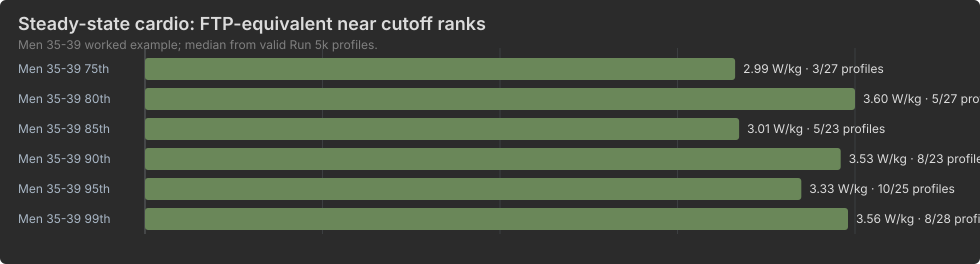

### High-energy cardio: 400m time near cutoff ranks

Division,Percentile,Median,Metric profiles,Target profiles,Anecdotal
Men,75th,1:05,2,26,yes
Men,80th,1:06,3,24,
Men,85th,1:01,1,27,yes
Men,90th,1:09,3,26,
Men,95th,1:02,4,27,
Men,99th,0:54,4,29,
Women,75th,,0,27,
Women,80th,1:44,2,27,yes
Women,85th,1:28,1,30,yes
Women,90th,,0,28,


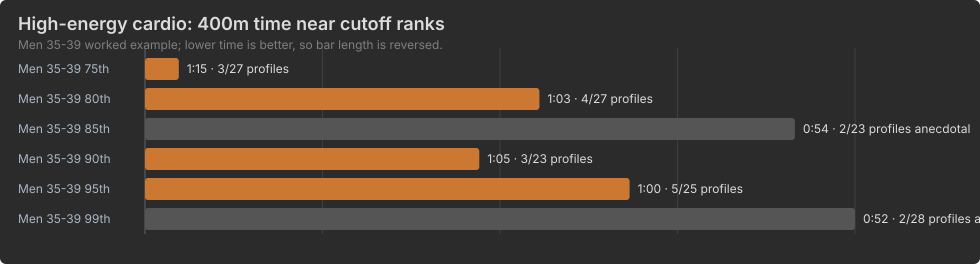

### Fast strength: clean & jerk 1RM near cutoff ranks

Division,Percentile,Median,Metric profiles,Target profiles,Anecdotal
Men,75th,100 kg,10,26,
Men,80th,103 kg,8,24,
Men,85th,103 kg,10,27,
Men,90th,123 kg,10,26,
Men,95th,127 kg,15,27,
Men,99th,144 kg,16,29,
Women,75th,62 kg,5,27,
Women,80th,65 kg,6,27,
Women,85th,72 kg,6,30,
Women,90th,81 kg,8,28,


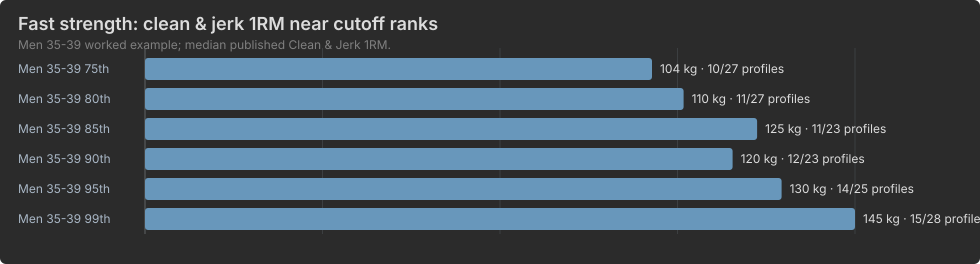

### Slow strength: CrossFit Total near cutoff ranks

Division,Percentile,Median,Metric profiles,Target profiles,Anecdotal
Men,75th,407 kg,2,26,yes
Men,80th,404 kg,3,24,
Men,85th,,0,27,
Men,90th,475 kg,2,26,yes
Men,95th,492 kg,2,27,yes
Men,99th,540 kg,3,29,
Women,75th,,0,27,
Women,80th,,0,27,
Women,85th,,0,30,
Women,90th,,0,28,


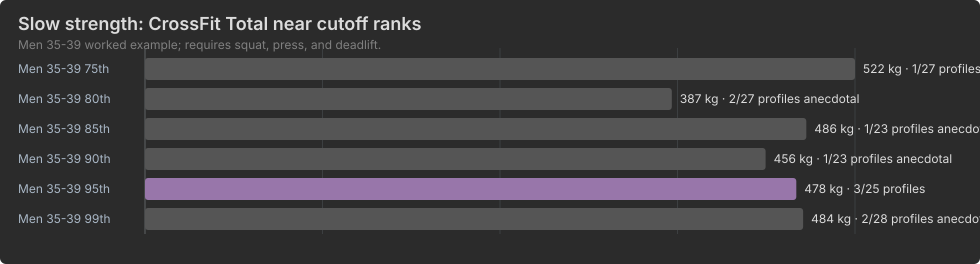

In [7]:
targeted_benchmark_path = Path("content/data/crossfit_open_2026_targeted_benchmark_stats_expanded.csv")
if not targeted_benchmark_path.exists():
    targeted_benchmark_path = Path("data/crossfit_open_2026_targeted_benchmark_stats_expanded.csv")

profile_manifest_path = Path("content/data/crossfit_open_2026_targeted_profile_manifest_expanded.csv")
if not profile_manifest_path.exists():
    profile_manifest_path = Path("data/crossfit_open_2026_targeted_profile_manifest_expanded.csv")

with targeted_benchmark_path.open(newline="", encoding="utf-8") as handle:
    targeted_benchmarks = list(csv.DictReader(handle))
with profile_manifest_path.open(newline="", encoding="utf-8") as handle:
    targeted_profile_manifest = list(csv.DictReader(handle))

TARGETED_PERCENTILES = tuple(sorted({int(row["target_percentile"]) for row in targeted_profile_manifest}))
assert TARGETED_PERCENTILES == (75, 80, 85, 90, 95, 99)

def run_5k_to_ftp_equivalent_wkg(seconds: float) -> float:
    running_speed_mps = 5000 / seconds
    critical_speed_mps = 0.92 * running_speed_mps
    return critical_speed_mps * 4.184 * 0.23

def in_range(value: float | None, low: float, high: float) -> bool:
    return value is not None and low <= value <= high

def benchmark_value_kg(stats: dict[str, dict[str, str]], name: str, low: float = 1, high: float = 500) -> float | None:
    row = stats.get(name)
    value = safe_float(row.get("value_kg")) if row else None
    return value if in_range(value, low, high) else None

def benchmark_time_seconds(stats: dict[str, dict[str, str]], name: str, low: float, high: float) -> float | None:
    row = stats.get(name)
    value = safe_float(row.get("time_seconds")) if row else None
    return value if in_range(value, low, high) else None

def crossfit_total_kg(stats: dict[str, dict[str, str]]) -> float | None:
    back_squat = benchmark_value_kg(stats, "Back Squat 1RM", 30, 400)
    shoulder_press = benchmark_value_kg(stats, "Shoulder Press 1RM", 15, 200)
    deadlift = benchmark_value_kg(stats, "Deadlift 1RM", 40, 450)
    parts = [back_squat, shoulder_press, deadlift]
    return sum(parts) if all(part is not None for part in parts) else None

def targeted_stats_by_athlete() -> dict[tuple[str, int, str], dict[str, dict[str, str]]]:
    grouped: dict[tuple[str, int, str], dict[str, dict[str, str]]] = defaultdict(dict)
    for row in targeted_benchmarks:
        key = (row["division_name"], int(row["target_percentile"]), row["athlete_id"])
        grouped[key][row["stat_name"]] = row
    return grouped

cohort_stats = targeted_stats_by_athlete()
cohort_order = [(division_name, percentile) for division_name in FOCUS_DIVISIONS for percentile in TARGETED_PERCENTILES]
manifest_by_cohort: dict[tuple[str, int], list[dict[str, str]]] = defaultdict(list)
for row in targeted_profile_manifest:
    manifest_by_cohort[(row["division_name"], int(row["target_percentile"]))].append(row)

def cohort_denominator(division_name: str, percentile: int) -> int:
    return len(manifest_by_cohort[(division_name, percentile)])

def cohort_http_ok(division_name: str, percentile: int) -> int:
    return sum(1 for row in manifest_by_cohort[(division_name, percentile)] if row["http_status"] == "200")

def cohort_any_benchmark(division_name: str, percentile: int) -> int:
    return sum(1 for row in manifest_by_cohort[(division_name, percentile)] if int(row["benchmark_stat_count"] or 0) > 0)

def cohort_values(division_name: str, percentile: int, metric: str) -> list[float]:
    values = []
    for (cohort_division, cohort_percentile, _athlete_id), stats in cohort_stats.items():
        if cohort_division != division_name or cohort_percentile != percentile:
            continue
        if metric == "ftp_equiv_wkg":
            run5k = benchmark_time_seconds(stats, "Run 5k", 900, 3600)
            if run5k:
                values.append(run_5k_to_ftp_equivalent_wkg(run5k))
        elif metric == "run_400_seconds":
            run400 = benchmark_time_seconds(stats, "Run 400m", 40, 240)
            if run400:
                values.append(run400)
        elif metric == "clean_jerk_kg":
            clean_jerk = benchmark_value_kg(stats, "Clean & Jerk 1RM", 25, 250)
            if clean_jerk:
                values.append(clean_jerk)
        elif metric == "crossfit_total_kg":
            total = crossfit_total_kg(stats)
            if total:
                values.append(total)
    return values

coverage_summary = [
    [
        fmt_int(len(targeted_profile_manifest)),
        fmt_int(len({row["athlete_id"] for row in targeted_profile_manifest})),
        fmt_int(sum(1 for row in targeted_profile_manifest if row["http_status"] == "200")),
        fmt_int(sum(1 for row in targeted_profile_manifest if row["http_status"] == "404")),
        fmt_int(sum(1 for row in targeted_profile_manifest if int(row["benchmark_stat_count"] or 0) > 0)),
    ]
]
display(hidden_html_table(
    ["Target rows", "Unique athletes", "HTTP 200", "HTTP 404", "Profiles with any benchmark"],
    coverage_summary,
    label="targeted benchmark crawl coverage",
))

def metric_rows(metric: str, formatter, color: str, chart_division: str = "Men 35-39") -> list[dict[str, object]]:
    rows = []
    medians = []
    for percentile in TARGETED_PERCENTILES:
        values = cohort_values(chart_division, percentile, metric)
        medians.append(median(values) if values else None)
    valid_medians = [value for value in medians if value is not None]
    worst_400m = max(valid_medians) if metric == "run_400_seconds" and valid_medians else None
    best_400m = min(valid_medians) if metric == "run_400_seconds" and valid_medians else None
    for percentile, value in zip(TARGETED_PERCENTILES, medians):
        denominator = cohort_denominator(chart_division, percentile)
        values = cohort_values(chart_division, percentile, metric)
        if value is not None:
            low_n = len(values) < 3
            suffix = " anecdotal" if low_n else ""
            display = f"{formatter(value)} · {len(values)}/{denominator} profiles{suffix}"
            row_color = "#555555" if low_n else color
            scale_value = value
            if metric == "run_400_seconds" and worst_400m is not None and best_400m is not None:
                scale_value = (worst_400m - value) + max(1, 0.05 * (worst_400m - best_400m))
        else:
            value = 0
            scale_value = 0
            display = f"no values · 0/{denominator} profiles"
            row_color = "#555555"
        rows.append({"label": f"{chart_division} {percentile}th", "value": value, "scale_value": scale_value, "display": display, "color": row_color})
    return rows

def metric_lookup_rows(metric: str, formatter) -> list[list[object]]:
    rows = []
    for division_name, percentile in cohort_order:
        values = cohort_values(division_name, percentile, metric)
        denominator = cohort_denominator(division_name, percentile)
        rows.append([
            division_name,
            f"{percentile}th",
            formatter(median(values)) if values else "",
            len(values),
            denominator,
            "yes" if 0 < len(values) < 3 else "",
        ])
    return rows

for title, metric, formatter, color, note in [
    ("Steady-state cardio: FTP-equivalent near cutoff ranks", "ftp_equiv_wkg", lambda value: f"{value:.2f} W/kg", "#6a8759", "Men 35-39 worked example; median from valid Run 5k profiles."),
    ("High-energy cardio: 400m time near cutoff ranks", "run_400_seconds", seconds_to_mmss, "#cc7832", "Men 35-39 worked example; lower time is better, so bar length is reversed."),
    ("Fast strength: clean & jerk 1RM near cutoff ranks", "clean_jerk_kg", lambda value: f"{value:.0f} kg", "#6897bb", "Men 35-39 worked example; median published Clean & Jerk 1RM."),
    ("Slow strength: CrossFit Total near cutoff ranks", "crossfit_total_kg", lambda value: f"{value:.0f} kg", "#9876aa", "Men 35-39 worked example; requires squat, press, and deadlift."),
]:
    display(Markdown(f"### {title}"))
    display(hidden_html_table(["Division", "Percentile", "Median", "Metric profiles", "Target profiles", "Anecdotal"], metric_lookup_rows(metric, formatter), label=f"{title} lookup"))
    display_svg(bar_svg(title, metric_rows(metric, formatter, color), note=note, left=145, width=980))


Use the benchmark ladders for directional target-setting, especially where profile counts are high. They are not physiological requirements for a percentile. They combine two layers: leaderboard percentile from the complete Open dataset, and self-reported profile PRs from athletes near that leaderboard cutoff.

A fuller benchmark release would crawl every public athlete profile from `athletes.csv`, keep missing profile fields explicit, and publish coverage rates by division and percentile band.
